In [25]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.preprocessing import*
from sklearn.model_selection import train_test_split
import keras 
import tensorflow
from keras.datasets  import cifar10
from keras.models import Sequential
from keras.layers import Dense,Flatten,Dropout

In [26]:
(x_train,y_train),(x_test,y_test) = cifar10.load_data()

/Users/anuragpanchal/Documents/DeepLearning/DeepLearning/venv/lib/python3.13/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


In [27]:
x_train.shape,y_train.shape,x_test.shape,y_test.shape

((50000, 32, 32, 3), (50000, 1), (10000, 32, 32, 3), (10000, 1))

In [28]:
label_dict =  {0:'airplane', 1:'automobile', 2:'bird', 3:'cat', 4:'deer', 5:'dog', 6:'frog', 7:'horse', 8:'ship', 9:'truck'}
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [29]:
class_names.index('dog')

5

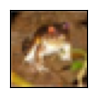

In [30]:
plt.figure(figsize=(1,1))
plt.imshow(x_train[0])
plt.xticks([])
plt.yticks([])
plt.show()

In [31]:
#EDA on this data 
# 5 images of each class 


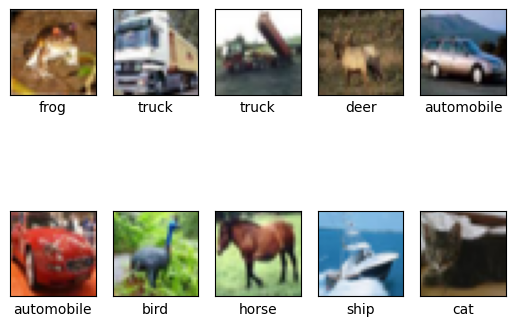

In [32]:
#make subplot where i want to print 10 images of different classes 
plt.Figure(figsize=(5,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_train[i])
    plt.xlabel(label_dict[y_train[i][0]])


In [33]:
np.where(y_train.flatten()==6)[0]

array([    0,    19,    22, ..., 49962, 49966, 49996], shape=(5000,))

In [34]:
#write a fxn which will take the class_name and additional argument which tells number of images and you have to print images belongs to that class 

def printimg(class_name="dog",num=10):
    #selecting the class index 
    index = class_names.index(class_name)
    print(index)
    # selecting all the index of the class 
    class_index = np.where(y_train.flatten()==index)[0]
    # electing random index of size num
    random_class_index = np.random.choice(class_index,num)
    
    for i in random_class_index:
        plt.figure(figsize=(1,1))
        plt.xticks([])
        plt.yticks([])
        plt.imshow(x_train[i])
        plt.xlabel(label_dict.get(y_train[i][0]))
        plt.show()



3


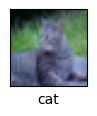

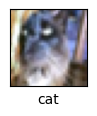

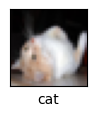

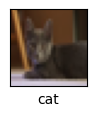

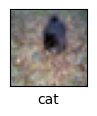

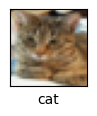

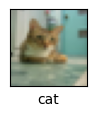

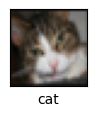

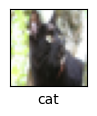

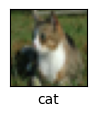

In [35]:
printimg(class_name='cat',num=10)

In [36]:
print("max:" ,np.max(x_train[0]))
print("min:" ,np.min(x_train[0]))

max: 255
min: 0


In [37]:
#create a simple ann 
x_train_scaled = x_train/255
x_test_scaled = x_test/255

In [38]:
x_train.shape

(50000, 32, 32, 3)

In [39]:
model  = Sequential(
    [
        Flatten(input_shape=(32,32,3)),
        Dense(128,activation='relu'),
        Dense(64,activation='relu'),
        Dropout(0.3),
        Dense(10,activation='softmax')
    ]
)
model.compile(optimizer='sgd',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
model.summary()

/Users/anuragpanchal/Documents/DeepLearning/DeepLearning/venv/lib/python3.13/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 402,250 (1.53 MB)

 Trainable params: 402,250 (1.53 MB)

 Non-trainable params: 0 (0.00 B)

In [40]:
model.fit(x_train_scaled,y_train,epochs=5,validation_data=(x_test,y_test))

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.2714 - loss: 1.9988 - val_accuracy: 0.3493 - val_loss: 135.8416
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 977us/step - accuracy: 0.3476 - loss: 1.8306 - val_accuracy: 0.3704 - val_loss: 151.9040
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 883us/step - accuracy: 0.3723 - loss: 1.7658 - val_accuracy: 0.3711 - val_loss: 150.8200
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 898us/step - accuracy: 0.3886 - loss: 1.7206 - val_accuracy: 0.4037 - val_loss: 143.9093
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 894us/step - accuracy: 0.4047 - loss: 1.6807 - val_accuracy: 0.4041 - val_loss: 174.5767


In [41]:
#convert all the images to grayscale 
x_train_grey = np.mean(x_train,axis=-1,keepdims=True)
x_test_grey = np.mean(x_test,axis=-1,keepdims=True)
max(x_train_grey[0].flatten()),min(x_train_grey[0].flatten())

(np.float64(246.66666666666666), np.float64(0.0))

In [42]:
x_train_grey_scaled = x_train_grey/np.max(x_train_grey[0].flatten())
x_test_grey_scaled = x_test_grey/np.max(x_train_grey[0].flatten())

In [43]:
model1  = Sequential(
    [
        Flatten(input_shape=(32,32)),
        Dense(128,activation='relu'),
        Dense(64,activation='relu'),
        Dropout(0.3),
        Dense(10,activation='softmax')
    ]
)
model1.compile(optimizer='sgd',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
model1.summary()
model1.fit(x_train_grey_scaled ,y_train,epochs=5,validation_data=(x_test_grey_scaled,y_test))

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 140,106 (547.29 KB)

 Trainable params: 140,106 (547.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 744us/step - accuracy: 0.2177 - loss: 2.1281 - val_accuracy: 0.2492 - val_loss: 2.0460
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 653us/step - accuracy: 0.2706 - loss: 2.0156 - val_accuracy: 0.3057 - val_loss: 1.9508
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 652us/step - accuracy: 0.2960 - loss: 1.9638 - val_accuracy: 0.3218 - val_loss: 1.9149
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 640us/step - accuracy: 0.3134 - loss: 1.9207 - val_accuracy: 0.3453 - val_loss: 1.8590
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 638us/step - accuracy: 0.3270 - loss: 1.8874 - val_accuracy: 0.3595 - val_loss: 1.8347


In [44]:
model2  = Sequential(
    [    
         keras.layers.Conv2D(5,(3,3),activation='relu',input_shape=(32,32,3)),
            keras.layers.MaxPool2D((2,2)),
         keras.layers.Conv2D(5,(3,3),activation='relu',input_shape=(32,32,3)),
            keras.layers.MaxPool2D((2,2)),
         keras.layers.Conv2D(5,(3,3),activation='relu',input_shape=(32,32,3)),
            keras.layers.MaxPool2D((2,2)),
        Flatten(),
        Dense(128,activation='relu'),
        
       
        Dense(10,activation='softmax')
    ]
)
model2.compile(optimizer='sgd',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
model2.summary()

/Users/anuragpanchal/Documents/DeepLearning/DeepLearning/venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 5)      │           140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 15, 15, 5)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 5)      │           230 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 5)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 5)        │           230 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 5)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,578 (17.88 KB)

 Trainable params: 4,578 (17.88 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
history2 = model2.fit(x_train_scaled ,y_train,epochs=5,validation_data=(x_test_scaled,y_test))

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1348 - loss: 2.2771 - val_accuracy: 0.1925 - val_loss: 2.1851
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.2430 - loss: 2.0498 - val_accuracy: 0.2815 - val_loss: 1.9724
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.2806 - loss: 1.9570 - val_accuracy: 0.3031 - val_loss: 1.9044
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.3080 - loss: 1.8832 - val_accuracy: 0.3466 - val_loss: 1.8231
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.3561 - loss: 1.7725 - val_accuracy: 0.3379 - val_loss: 1.8015


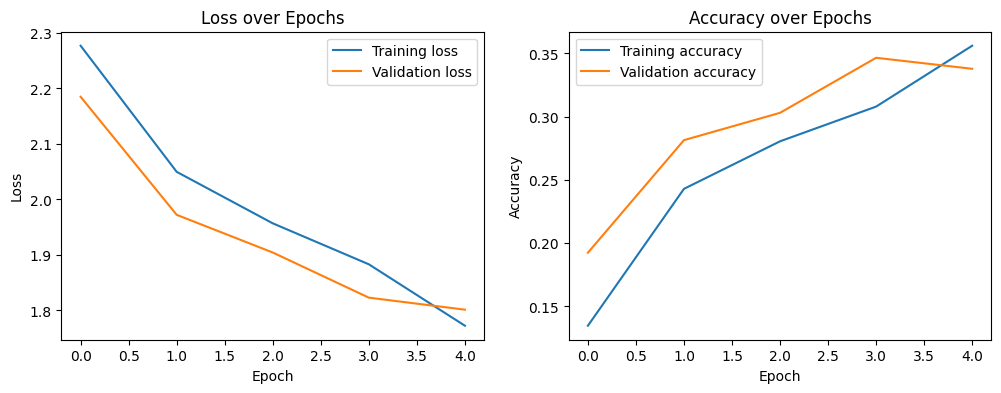

In [46]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history2.history['loss'],label='Training loss')
plt.plot(history2.history['val_loss'],label='Validation loss')
plt.title("Loss over Epochs")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()


plt.subplot(1,2,2)
plt.plot(history2.history['accuracy'],label='Training accuracy')
plt.plot(history2.history['val_accuracy'],label='Validation accuracy')
plt.title("Accuracy over Epochs")
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()




Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 30, 30, 5)      │           140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 5)      │            20 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 15, 15, 5)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 5)      │           230 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 5)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 4, 4, 5)        │           230 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 2, 2, 5)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,598 (17.96 KB)

 Trainable params: 4,588 (17.92 KB)

 Non-trainable params: 10 (40.00 B)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.2015 - loss: 2.1108 - val_accuracy: 0.2686 - val_loss: 1.9501
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.3222 - loss: 1.8023 - val_accuracy: 0.3331 - val_loss: 1.8251
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.3730 - loss: 1.6926 - val_accuracy: 0.3756 - val_loss: 1.7019
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.3940 - loss: 1.6476 - val_accuracy: 0.3787 - val_loss: 1.6941
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.4085 - loss: 1.6112 - val_accuracy: 0.3782 - val_loss: 1.7566


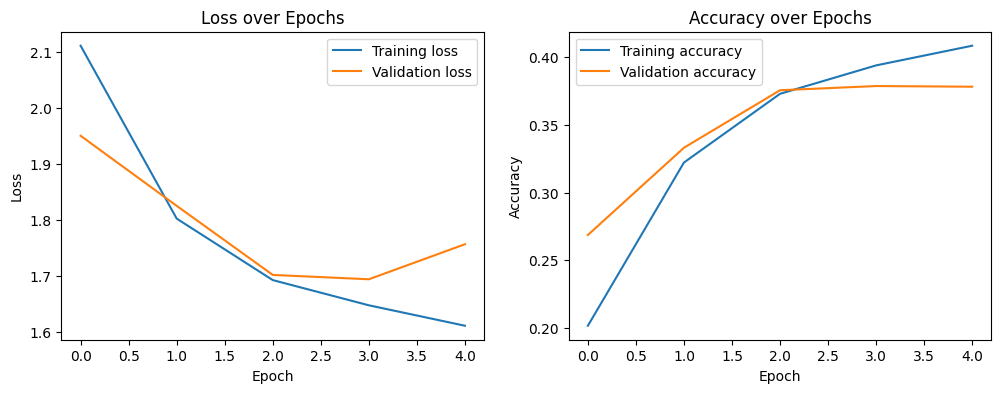

In [47]:
#model2 with batch normalization

model2  = Sequential(
    [    
         keras.layers.Conv2D(5,(3,3),activation='relu',input_shape=(32,32,3)),
         keras.layers.BatchNormalization(),
            keras.layers.MaxPool2D((2,2)),
         keras.layers.Conv2D(5,(3,3),activation='relu',input_shape=(32,32,3)),
            keras.layers.MaxPool2D((2,2)),
         keras.layers.Conv2D(5,(3,3),activation='relu',input_shape=(32,32,3)),
            keras.layers.MaxPool2D((2,2)),
        Flatten(),
        Dense(128,activation='relu'),
        
       
        Dense(10,activation='softmax')
    ]
)
model2.compile(optimizer='sgd',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
model2.summary()
history2 = model2.fit(x_train_scaled ,y_train,epochs=5,validation_data=(x_test_scaled,y_test))
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history2.history['loss'],label='Training loss')
plt.plot(history2.history['val_loss'],label='Validation loss')
plt.title("Loss over Epochs")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()


plt.subplot(1,2,2)
plt.plot(history2.history['accuracy'],label='Training accuracy')
plt.plot(history2.history['val_accuracy'],label='Validation accuracy')
plt.title("Accuracy over Epochs")
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,105,482 (4.22 MB)

 Trainable params: 1,105,290 (4.22 MB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 44s 28ms/step - accuracy: 0.3446 - loss: 1.8278 - val_accuracy: 0.4661 - val_loss: 1.4929
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 45s 29ms/step - accuracy: 0.4749 - loss: 1.4670 - val_accuracy: 0.4600 - val_loss: 1.5718
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 49s 31ms/step - accuracy: 0.5313 - loss: 1.3171 - val_accuracy: 0.6046 - val_loss: 1.1220
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 56s 36ms/step - accuracy: 0.5776 - loss: 1.2060 - val_accuracy: 0.6145 - val_loss: 1.0781
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 56s 36ms/step - accuracy: 0.6064 - loss: 1.1285 - val_accuracy: 0.5763 - val_loss: 1.2195


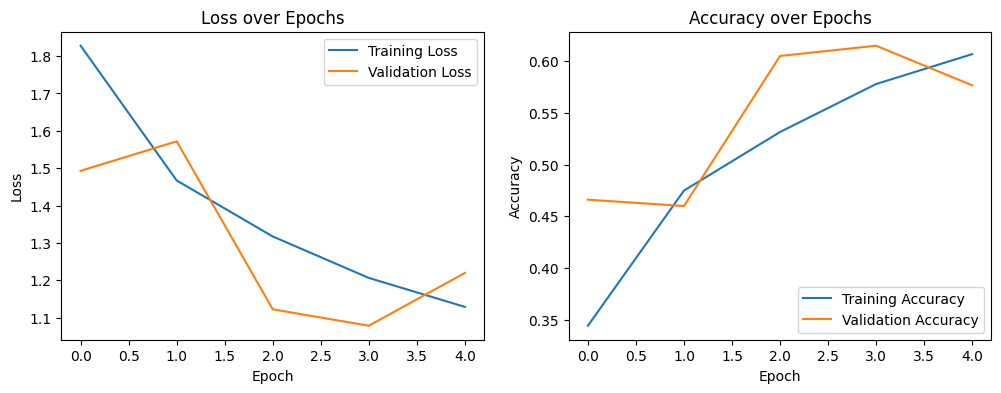

In [48]:
# Set the CNN model
from keras import models, layers

model = models.Sequential()
model.add(layers.Conv2D(32, (5, 5), padding='same', activation="relu", input_shape=(32,32,3)))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.3))
model.add(layers.Conv2D(64, (5, 5), padding='same', activation="relu"))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.4))

model.add(layers.Flatten())
model.add(layers.Dense(256, activation="relu"))
model.add(layers.Dropout(0.5))
# softmax
model.add(layers.Dense(10, activation="softmax"))

model.summary()

# initiate Adam optimizer
from keras import optimizers
opt = optimizers.Adam(learning_rate=0.001)
# Let's train the model using RMSprop
model.compile(loss='sparse_categorical_crossentropy',
              optimizer=opt,
              metrics=['accuracy'])

# Train the model
history=model.fit(x_train,y_train,epochs=5,validation_data=(x_test,y_test))

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [49]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_data_design = ImageDataGenerator(
                    rotation_range=15,
                    width_shift_range=0.1,
                    height_shift_range=0.1,
                    horizontal_flip=True,
                    shear_range=0.1,
                    zoom_range=.1

)

In [50]:
x_train_data_generator = train_data_design.flow(x_train, y_train, batch_size=64)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_17 (Conv2D)              │ (None, 30, 30, 5)      │           140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 15, 15, 5)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 13, 13, 5)      │           230 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 6, 6, 5)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 4, 4, 5)        │           230 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 2, 2, 5)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,578 (17.88 KB)

 Trainable params: 4,578 (17.88 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.0978 - loss: 7.2176 - val_accuracy: 0.0996 - val_loss: 2.3026
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.0976 - loss: 2.3027 - val_accuracy: 0.0998 - val_loss: 2.3026
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.0981 - loss: 2.3026 - val_accuracy: 0.0999 - val_loss: 2.3026
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.0977 - loss: 2.3027 - val_accuracy: 0.1001 - val_loss: 2.3026
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.0979 - loss: 2.3026 - val_accuracy: 0.1006 - val_loss: 2.3026


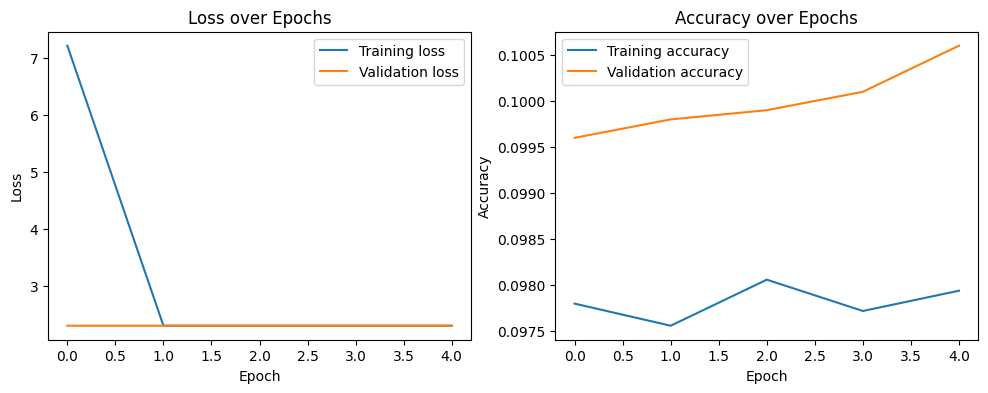

In [53]:
model2  = Sequential(
    [    
         keras.layers.Conv2D(5,(3,3),activation='relu',input_shape=(32,32,3)),
            keras.layers.MaxPool2D((2,2)),
         keras.layers.Conv2D(5,(3,3),activation='relu',input_shape=(32,32,3)),
            keras.layers.MaxPool2D((2,2)),
         keras.layers.Conv2D(5,(3,3),activation='relu',input_shape=(32,32,3)),
            keras.layers.MaxPool2D((2,2)),
        Flatten(),
        Dense(128,activation='relu'),
        
       
        Dense(10,activation='softmax')
    ]
)
model2.compile(optimizer='sgd',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
model2.summary()
history2 = model2.fit(x_train_data_generator ,epochs=5,validation_data=(x_test,y_test))
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history2.history['loss'],label='Training loss')
plt.plot(history2.history['val_loss'],label='Validation loss')
plt.title("Loss over Epochs")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()


plt.subplot(1,2,2)
plt.plot(history2.history['accuracy'],label='Training accuracy')
plt.plot(history2.history['val_accuracy'],label='Validation accuracy')
plt.title("Accuracy over Epochs")
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [57]:
base_vgg = keras.applications.VGG16(
    include_top=False,
    weights='imagenet',
    input_shape=(32,32,3)
)
base_vgg.trainable=False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [58]:
(x_train,y_train),(x_test,y_test) = cifar10.load_data()

/Users/anuragpanchal/Documents/DeepLearning/DeepLearning/venv/lib/python3.13/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


In [60]:
base_vgg.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [62]:
model = Sequential()
model.add(base_vgg)
model.add(Flatten())
model.add(Dense(64,activation='relu'))
model.add(Dense(10,activation='softmax'))

In [ ]:
# model=Sequential([
#     base_vgg,
#     Flatten(),
#     Dense(64,activation='relu'),
#     Dense(10,activation='softmax')

# ])

In [63]:
model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,748,170 (56.26 MB)

 Trainable params: 33,482 (130.79 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [64]:
model.compile(optimizer='sgd',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [65]:
history = model.fit(x_train,y_train,epochs=5,validation_data=(x_test,y_test))

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 138s 87ms/step - accuracy: 0.4160 - loss: 1.7601 - val_accuracy: 0.4498 - val_loss: 1.5997
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 162s 104ms/step - accuracy: 0.5228 - loss: 1.3809 - val_accuracy: 0.5342 - val_loss: 1.4111
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 166s 106ms/step - accuracy: 0.5568 - loss: 1.2983 - val_accuracy: 0.5584 - val_loss: 1.3142
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 167s 107ms/step - accuracy: 0.5741 - loss: 1.2505 - val_accuracy: 0.5673 - val_loss: 1.3237
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 167s 107ms/step - accuracy: 0.5871 - loss: 1.2212 - val_accuracy: 0.5662 - val_loss: 1.3455
